## Appearance-Based Model (Option B)

Train and evaluate the appearance-based classifier. Include metric reporting and a brief comparison to other model options.


In [3]:
from pathlib import Path
import sys

# Add repository root so src imports work when running from notebooks/.
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.config import (
    PART1_KAGGLE_DIR,
    PART2_IMAGES_DIR,
    PART2_ANNOTATIONS_DIR,
    validate_data_layout,
)

validate_data_layout()

print("Data paths validated:")
print(f"- Part 1: {PART1_KAGGLE_DIR}")
print(f"- Part 2 Images: {PART2_IMAGES_DIR}")
print(f"- Part 2 Annotations: {PART2_ANNOTATIONS_DIR}")

Data paths validated:
- Part 1: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/data/part1/data/kaggle
- Part 2 Images: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/data/part2/Stanford Dog Dataset/Images
- Part 2 Annotations: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/data/part2/Stanford Dog Dataset/Annotation


In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from src.config import OUTPUTS_DIR, IMG_SIZE_CLASSICAL
from src.utils import (
    load_labeled_images,
    split_data,
    apply_pca,
    load_test_images,
    generate_submission_csv,
)
from src.evaluation import compute_metrics, compute_confusion_matrix, compare_models
from src.visualization import (
    plot_confusion_matrix,
    plot_sample_predictions,
    plot_model_comparison,
)


In [5]:
# Load labeled images for appearance-based modeling
X, y = load_labeled_images(img_size=IMG_SIZE_CLASSICAL, grayscale=True)

print(f"Loaded images shape: {X.shape}")
print(f"Loaded labels shape: {y.shape}")
print(f"Class distribution: {np.bincount(y)}  (cat, dog)")


Loading dogs: 100%|██████████| 9979/9979 [00:06<00:00, 1603.28it/s]


Loaded images shape: (20000, 128, 128)
Loaded labels shape: (20000,)
Class distribution: [10021  9979]  (cat, dog)


In [6]:
# Split labeled data into train and internal test sets
X_train, X_test, y_train, y_test = split_data(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Test set:  {X_test.shape}, {y_test.shape}")


Train set: (16000, 128, 128), (16000,)
Test set:  (4000, 128, 128), (4000,)


In [7]:
# Train PCA-based models with different numbers of components
pca_components_list = [50, 100, 150, 200]

results = {}
best_accuracy = -1.0
best_n_components = None
best_model = None
best_pca = None
best_y_pred = None
best_X_test_pca = None

for n_components in pca_components_list:
    X_train_pca, X_test_pca, pca = apply_pca(
        X_train,
        X_test,
        n_components=n_components,
    )

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)
    metrics = compute_metrics(y_test, y_pred)

    model_name = f"PCA-{n_components}+LogReg"
    results[model_name] = metrics

    print(f"{model_name} -> {metrics}")

    if metrics["accuracy"] > best_accuracy:
        best_accuracy = metrics["accuracy"]
        best_n_components = n_components
        best_model = model
        best_pca = pca
        best_y_pred = y_pred
        best_X_test_pca = X_test_pca

print()
print(f"Best Option B setup: PCA-{best_n_components}+LogReg")
print(f"Best accuracy: {best_accuracy:.4f}")


PCA-50+LogReg -> {'accuracy': 0.5685, 'precision': 0.5688775510204082, 'recall': 0.5586172344689379, 'f1': 0.5637007077856421}
PCA-100+LogReg -> {'accuracy': 0.57025, 'precision': 0.5697030699547055, 'recall': 0.5671342685370742, 'f1': 0.5684157670097916}
PCA-150+LogReg -> {'accuracy': 0.56275, 'precision': 0.5625950329447542, 'recall': 0.5561122244488977, 'f1': 0.5593348450491308}
PCA-200+LogReg -> {'accuracy': 0.55975, 'precision': 0.5594936708860759, 'recall': 0.5536072144288577, 'f1': 0.5565348778645177}

Best Option B setup: PCA-100+LogReg
Best accuracy: 0.5703


In [8]:
# Compare Option B configurations in a metrics table
comparison_df = compare_models(results)
comparison_df


,accuracy,precision,recall,f1
model,,,,
PCA-100+LogReg,0.57025,0.569703,0.567134,0.568416
PCA-50+LogReg,0.56850,0.568878,0.558617,0.563701
PCA-150+LogReg,0.56275,0.562595,0.556112,0.559335
PCA-200+LogReg,0.55975,0.559494,0.553607,0.556535


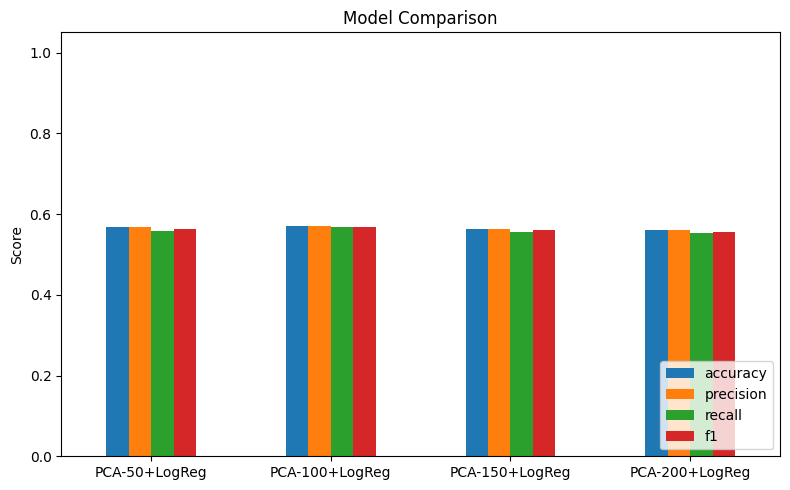

In [9]:
# Plot grouped metric comparison across Option B configurations
plot_model_comparison(results)


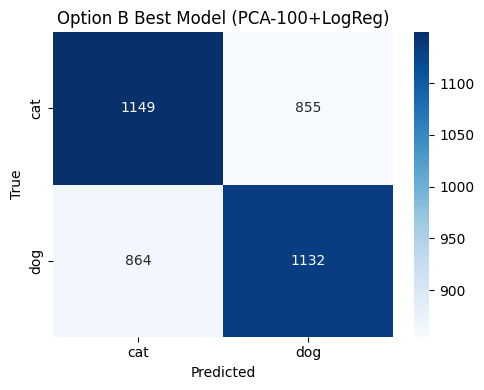

In [10]:
# Compute and display confusion matrix for the best Option B model
best_cm = compute_confusion_matrix(y_test, best_y_pred)
plot_confusion_matrix(best_cm, title=f"Option B Best Model (PCA-{best_n_components}+LogReg)")


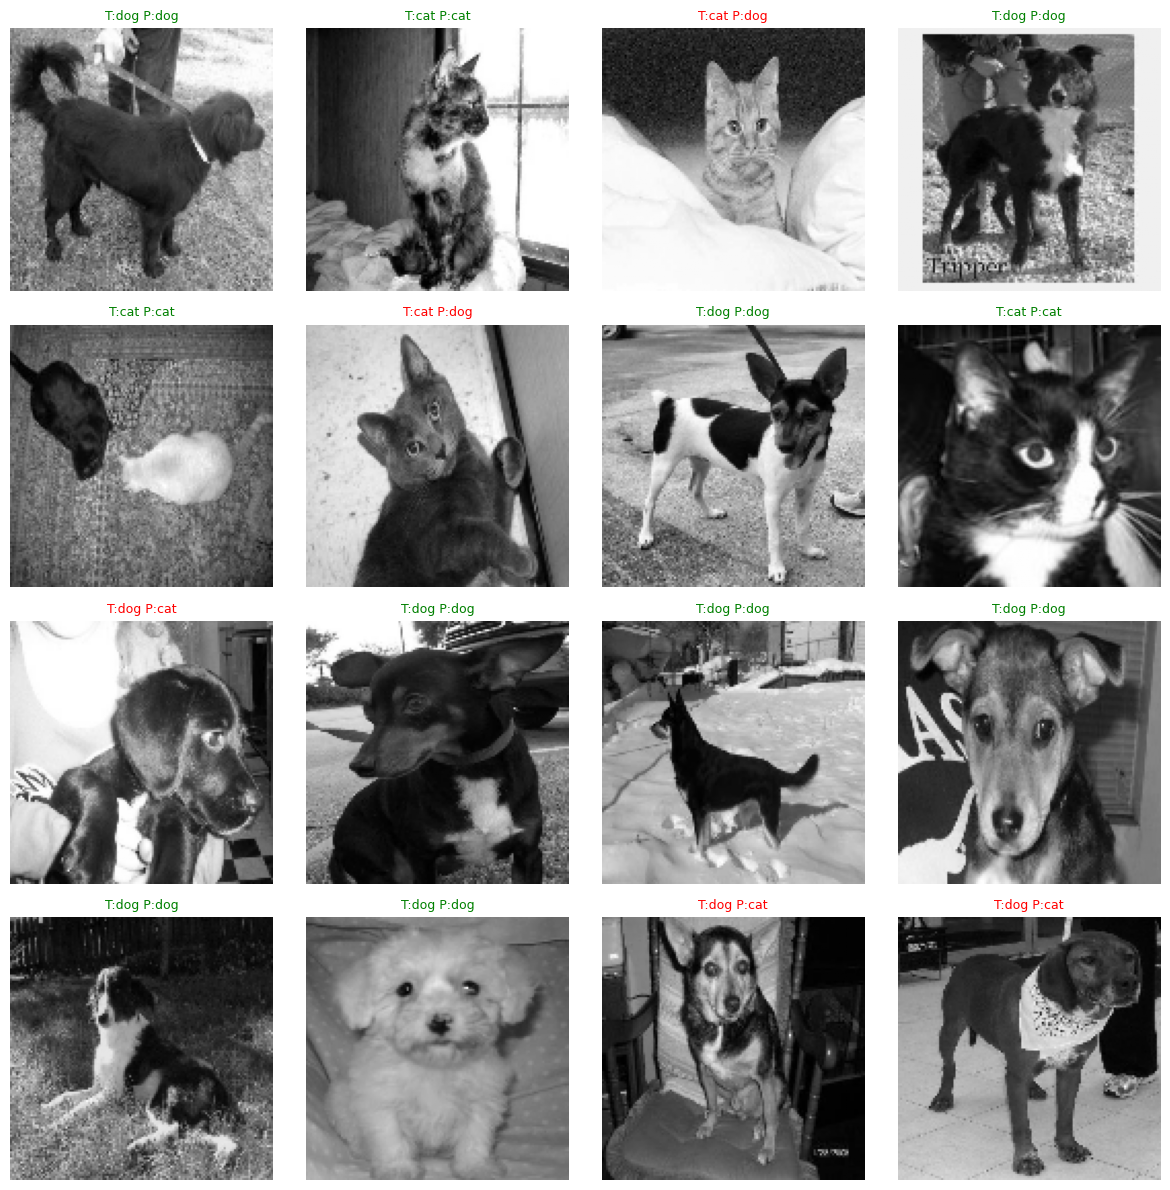

In [11]:
# Show sample predictions from the internal test split
plot_sample_predictions(
    images=X_test,
    y_true=y_test,
    y_pred=best_y_pred,
    n=16,
)


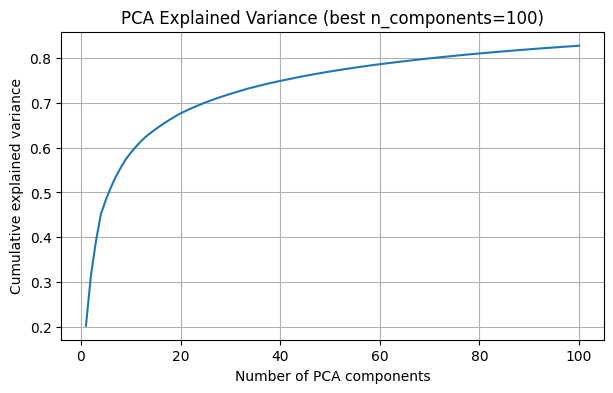

In [12]:
# Plot cumulative explained variance for the selected PCA model
explained_variance_ratio = best_pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title(f"PCA Explained Variance (best n_components={best_n_components})")
plt.grid(True)
plt.show()


In [15]:
# Generate Kaggle predictions with the best Option B model
X_kaggle_test, kaggle_ids = load_test_images(
    img_size=IMG_SIZE_CLASSICAL,
    grayscale=True,
)

X_kaggle_test_flat = X_kaggle_test.reshape(X_kaggle_test.shape[0], -1)
X_kaggle_test_pca = best_pca.transform(X_kaggle_test_flat)
kaggle_pred = best_model.predict(X_kaggle_test_pca)
kaggle_pred_proba = best_model.predict_proba(X_kaggle_test_pca)[:, 1]

submission_path = OUTPUTS_DIR / "submissions" / "optionB_pca_logreg_submission.csv"
submission_path = generate_submission_csv(kaggle_ids, kaggle_pred, submission_path)

debug_submission_path = OUTPUTS_DIR / "tests" / "optionB_pca_logreg_submission_proba.csv"
debug_submission_path = generate_submission_csv(kaggle_ids, kaggle_pred_proba, debug_submission_path)

print(f"Submission saved to: {submission_path}")
print(f"Debug probabilities saved to: {debug_submission_path}")


Loading test images: 100%|██████████| 5000/5000 [00:02<00:00, 1792.27it/s]


Submission saved to: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/outputs/submissions/optionB_pca_logreg_submission.csv
Debug probabilities saved to: /Users/thomascottereau/Documents/lifehub/uni/courses/ecse/415/06-projects/final-project/ecse415-final-project/outputs/tests/optionB_pca_logreg_submission_proba.csv


### Notes for report (Part 1 Option B)

- Report the best `n_components` and the corresponding accuracy, precision, recall, and F1.
- Include the confusion matrix figure from the internal test split.
- Compare this Option B result against your Option A and Option C models.
- Briefly discuss compute cost and failure patterns seen in the sample prediction grid.
